<a href="https://colab.research.google.com/github/brvndon266/MAE249_Soft_Robotics/blob/main/Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

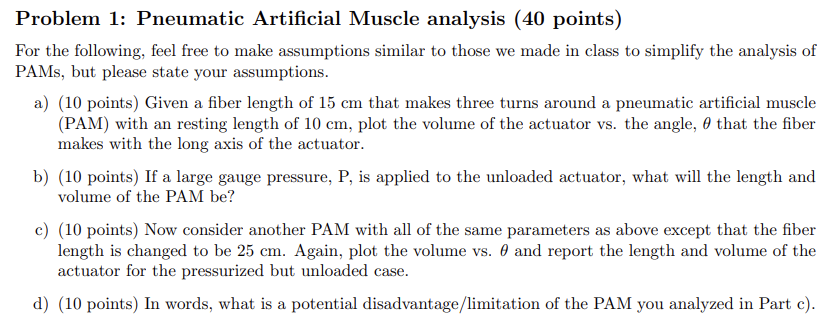

Problem 1 - Part A
---

Resting angle θ_rest = 48.1897°
Resting volume V_rest = 11.0524 cm³


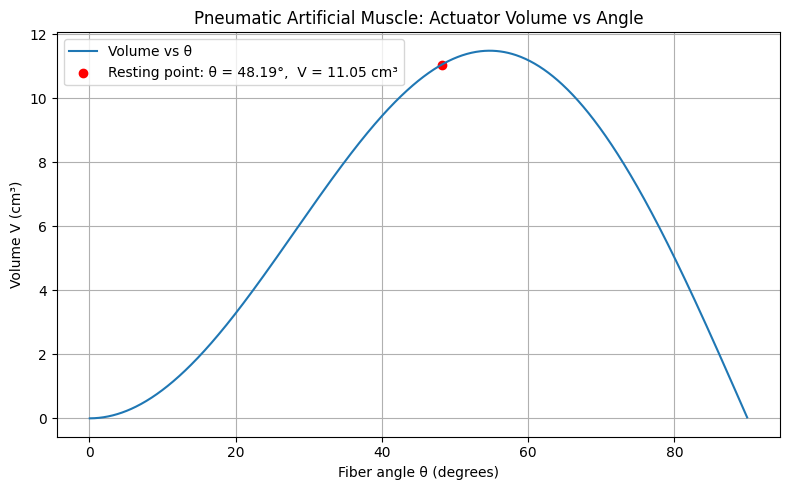

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters (Part a) ---
b = 15.0      # fiber length [cm]
n = 3         # number of turns
L_rest = 10.0 # resting length [cm]
pi = np.pi

# --- Volume formula ---
# V(θ) = (b^3 / (4πn^2)) * sin^2(θ) * cos(θ)
def V_of_theta(b, n, theta):
    return (b**3 / (4 * pi * n**2)) * (np.sin(theta)**2) * np.cos(theta)

# --- θ range (from nearly 0° to 90°) ---
theta = np.linspace(1e-3, np.pi/2 - 1e-3, 1000)

# --- Compute V(θ) ---
V = V_of_theta(b, n, theta)

# --- Resting angle (from L = b cosθ) ---
theta_rest = np.arccos(L_rest / b)  # radians
V_rest = V_of_theta(b, n, theta_rest)

# --- Print results ---
print(f"Resting angle θ_rest = {np.degrees(theta_rest):.4f}°")
print(f"Resting volume V_rest = {V_rest:.4f} cm³")

# --- Plot Volume vs θ ---
plt.figure(figsize=(8,5))
plt.plot(np.degrees(theta), V, label='Volume vs θ')
plt.scatter(np.degrees(theta_rest), V_rest, color='red',
label=f"Resting point: θ = {np.degrees(theta_rest):.2f}°,  V = {V_rest:.2f} cm³")
plt.xlabel("Fiber angle θ (degrees)")
plt.ylabel("Volume V (cm³)")
plt.title("Pneumatic Artificial Muscle: Actuator Volume vs Angle")
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


Problem 1 - Part C
---


Resting angle θ_rest = 66.4218°
Resting volume V_rest = 46.4202 cm³


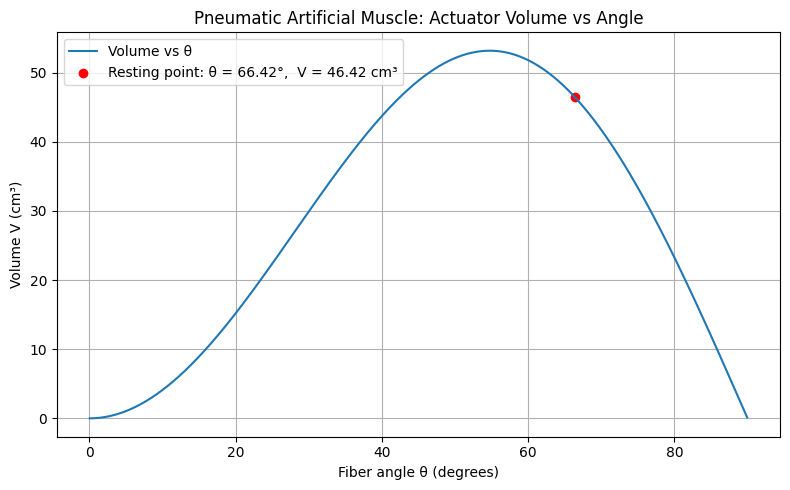

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters (Part a) ---
b = 25.0      # fiber length [cm]
n = 3         # number of turns
L_rest = 10.0 # resting length [cm]
pi = np.pi

# --- Volume formula ---
# V(θ) = (b^3 / (4πn^2)) * sin^2(θ) * cos(θ)
def V_of_theta(b, n, theta):
    return (b**3 / (4 * pi * n**2)) * (np.sin(theta)**2) * np.cos(theta)

# --- θ range (from nearly 0° to 90°) ---
theta = np.linspace(1e-3, np.pi/2 - 1e-3, 1000)

# --- Compute V(θ) ---
V = V_of_theta(b, n, theta)

# --- Resting angle (from L = b cosθ) ---
theta_rest = np.arccos(L_rest / b)  # radians
V_rest = V_of_theta(b, n, theta_rest)

# --- Print results ---
print(f"Resting angle θ_rest = {np.degrees(theta_rest):.4f}°")
print(f"Resting volume V_rest = {V_rest:.4f} cm³")

# --- Plot Volume vs θ ---
plt.figure(figsize=(8,5))
plt.plot(np.degrees(theta), V, label='Volume vs θ')
plt.scatter(np.degrees(theta_rest), V_rest, color='red',
label=f"Resting point: θ = {np.degrees(theta_rest):.2f}°,  V = {V_rest:.2f} cm³")
plt.xlabel("Fiber angle θ (degrees)")
plt.ylabel("Volume V (cm³)")
plt.title("Pneumatic Artificial Muscle: Actuator Volume vs Angle")
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


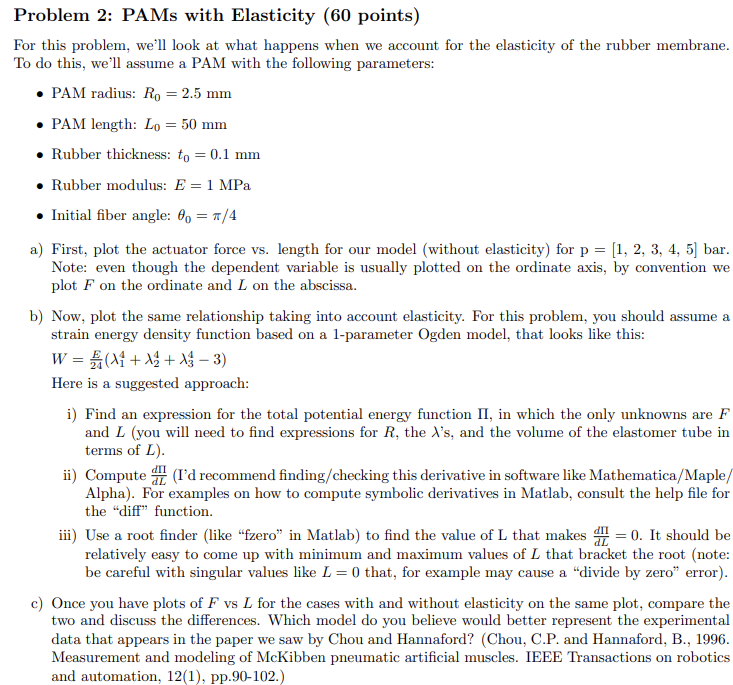

Problem 2 - Part A
---

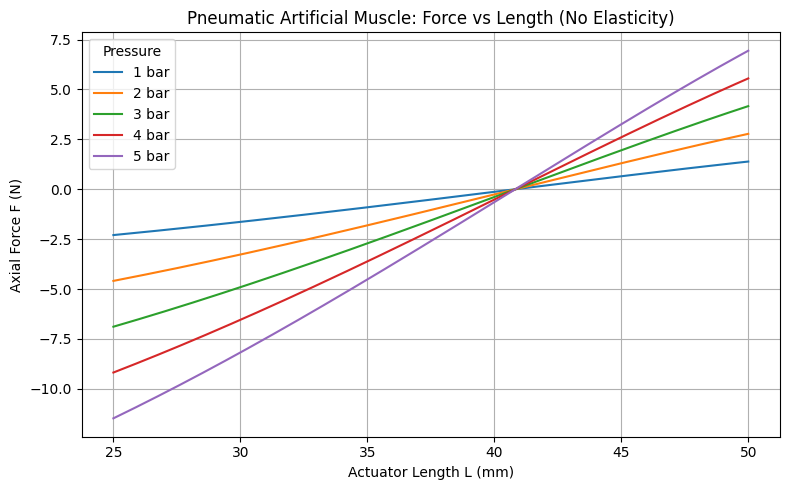

Fiber length b = 70.71 mm
Number of turns n = 3.183


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters ---
R0 = 2.5e-3    # m
L0 = 50e-3     # m
theta0 = np.pi / 4  # rad
pressures_bar = np.array([1, 2, 3, 4, 5])  # bar
pressures = pressures_bar * 1e5  # Pa

pi = np.pi

# --- Geometry relationships ---
b = L0 / np.cos(theta0)
n = (b * np.sin(theta0)) / (2 * pi * R0)

# --- Force(L) model (without elasticity) ---
def F_of_L(L, p, b, n):
    cos_theta = L / b
    sin_theta = np.sqrt(1 - cos_theta**2)
    return (p * b**2 / (4 * pi * n**2)) * sin_theta * (3 * cos_theta**2 - 1)

# --- Range of L (avoid too small or too large angles) ---
L_vals = np.linspace(0.5 * L0, L0, 200)  # 50% to 100% of L0

# --- Plot F vs L for different pressures ---
plt.figure(figsize=(8, 5))
for p_bar, p in zip(pressures_bar, pressures):
    F_vals = F_of_L(L_vals, p, b, n)
    plt.plot(L_vals * 1000, F_vals, label=f"{p_bar} bar")

plt.xlabel("Actuator Length L (mm)")
plt.ylabel("Axial Force F (N)")
plt.title("Pneumatic Artificial Muscle: Force vs Length (No Elasticity)")
plt.grid(True)
plt.legend(title="Pressure")
plt.tight_layout()
plt.show()

# --- Print constants for reference ---
print(f"Fiber length b = {b*1000:.2f} mm")
print(f"Number of turns n = {n:.3f}")


Problem 2
---

Rubber cross-sectional area A_rubber = 1.571 mm²


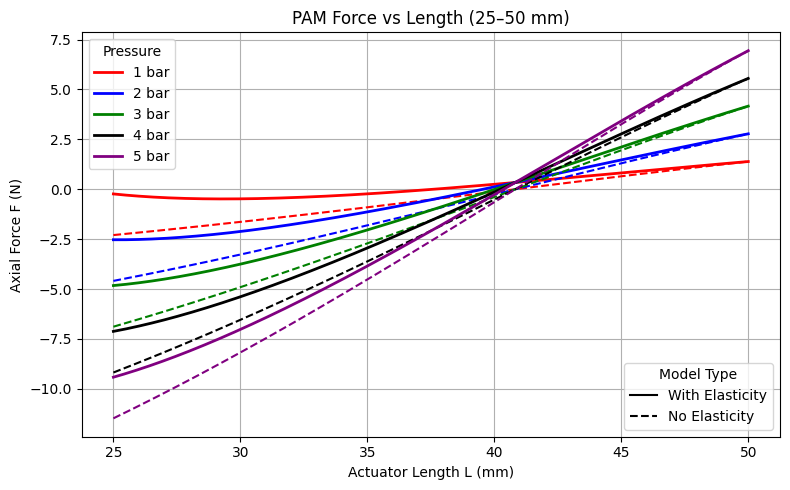

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Given parameters ---
R0 = 2.5e-3    # m
L0 = 50e-3     # m
t0 = 0.1e-3    # m   # wall thickness
E = 1e6        # Pa  # Young's modulus
theta0 = np.pi / 4   # rad
pressures_bar = np.array([1, 2, 3, 4, 5])  # bar
pressures = pressures_bar * 1e5  # Pa

# --- Geometry relationships ---
b = L0 / np.cos(theta0)
n = (b * np.sin(theta0)) / (2 * np.pi * R0)

# --- Rubber cross-sectional area (thin-wall approximation) ---
A_rubber = 2 * np.pi * R0 * t0
print(f"Rubber cross-sectional area A_rubber = {A_rubber*1e6:.3f} mm²")

# --- Force(L) models ---
def F_geometry(L, p, b, n):
    cos_theta = L / b
    sin_theta = np.sqrt(1 - cos_theta**2)
    return (p * b**2 / (4 * np.pi * n**2)) * sin_theta * (3 * cos_theta**2 - 1)

def F_elastic(L, L0, E, A_rubber):
    lam = L / L0
    return A_rubber * (E / 6) * (lam**3 - lam**-3)

def F_total(L, p, b, n, L0, E, A_rubber):
    return F_geometry(L, p, b, n) - F_elastic(L, L0, E, A_rubber)

# --- Range of L (25–50 mm) ---
L_vals = np.linspace(25e-3, 50e-3, 300)

colors = ['red', 'blue', 'green', 'black', 'purple']

# --- Plot setup ---
plt.figure(figsize=(8, 5))

for (p_bar, p, color) in zip(pressures_bar, pressures, colors):
    F_geom = F_geometry(L_vals, p, b, n)
    F_elast = F_total(L_vals, p, b, n, L0, E, A_rubber)

    plt.plot(L_vals * 1000, F_geom, '--', color=color, linewidth=1.5)
    plt.plot(L_vals * 1000, F_elast, '-', color=color, linewidth=2, label=f"{p_bar} bar")

# --- Custom legend elements for line styles ---
legend_lines = [
    Line2D([0], [0], color='black', linestyle='-', label='With Elasticity'),
    Line2D([0], [0], color='black', linestyle='--', label='No Elasticity')
]

# --- Labels ---
plt.xlabel("Actuator Length L (mm)")
plt.ylabel("Axial Force F (N)")
plt.title("PAM Force vs Length (25–50 mm)")
plt.grid(True)

# Combine legends
first_legend = plt.legend(handles=legend_lines, loc='lower right', title="Model Type")
plt.gca().add_artist(first_legend)
plt.legend(title="Pressure", loc='best')

plt.tight_layout()
plt.show()
